In [11]:
import os
from google.colab import userdata

# 1. Access your Secret Keys (The 'Notebook access' toggle MUST be blue)
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✅ Kaggle Credentials successfully pulled from Secrets.")
except Exception as e:
    print(f"❌ ERROR: {e}")
    print("Go to the 'Key' icon on the left, find your KAGGLE keys, and turn ON the 'Notebook access' switch.")

# 2. Create the massive dataset structure
!mkdir -p stray-dog-cnn/data/low_risk
!mkdir -p stray-dog-cnn/data/medium_risk
!mkdir -p stray-dog-cnn/data/critical_risk

print("📂 Project folders created in Colab storage.")

✅ Kaggle Credentials successfully pulled from Secrets.
📂 Project folders created in Colab storage.


In [3]:
import shutil
import glob
import os

# 1. Download & Unzip (Colab speeds are usually 100MB/s+)
print("🚀 Downloading Stanford (Healthy) and Disease (Sick) datasets...")
!kaggle datasets download -d miljan/stanford-dogs-dataset-traintest
!kaggle datasets download -d yashmotiani/dogs-skin-disease-dataset

print("📦 Unzipping files... (This takes about 20 seconds)")
!unzip -q stanford-dogs-dataset-traintest.zip -d ./temp_healthy
!unzip -q dogs-skin-disease-dataset.zip -d ./temp_unhealthy

# 2. Data Balancing Script (Target: 1,000 images per class)
base_path = './stray-dog-cnn/data'

# Low Risk: Grab 1,000 from Stanford
print("💉 Filling 'low_risk' with 1,000 Healthy dogs...")
h_imgs = glob.glob('./temp_healthy/cropped/train/**/*.jpg', recursive=True)
for i, img in enumerate(h_imgs[:1000]):
    shutil.copy(img, f'{base_path}/low_risk/h_{i}.jpg')

# Medium & Critical: Boost existing sick photos to 1,000 each
def boost_category(src_paths, category_name, target=1000):
    files = []
    for p in src_paths:
        files.extend(glob.glob(os.path.join(p, '*.jpg')))

    if not files:
        print(f"❌ Error: No files found for {category_name} at paths {src_paths}")
        return

    for i in range(target):
        # Loops back to the start of the list if we run out (Modulo %)
        shutil.copy(files[i % len(files)], f'{base_path}/{category_name}/s_{i}.jpg')
    print(f"✅ {category_name} filled with {target} images.")

# Medium: Fungal/Allergic
boost_category([
    './temp_unhealthy/Dogs/Fungal_infections',
    './temp_unhealthy/Dogs/Hypersensitivity_allergic_dermatosis'
], 'medium_risk')

# Critical: Bacterial Dermatosis
boost_category(['./temp_unhealthy/Dogs/Bacterial_dermatosis'], 'critical_risk')

print("\n🔥 3,000 IMAGES READY: Dataset balanced for training.")

🚀 Downloading Stanford (Healthy) and Disease (Sick) datasets...
Dataset URL: https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
License(s): other
100% 393M/393M [00:03<00:00, 134MB/s]

Dataset URL: https://www.kaggle.com/datasets/yashmotiani/dogs-skin-disease-dataset
License(s): CC0-1.0
100% 188M/188M [00:01<00:00, 119MB/s]

📦 Unzipping files... (This takes about 20 seconds)
💉 Filling 'low_risk' with 1,000 Healthy dogs...
✅ medium_risk filled with 1000 images.
✅ critical_risk filled with 1000 images.

🔥 3,000 IMAGES READY: Dataset balanced for training.


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup the Generator with Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels
    validation_split=0.2,     # 20% for testing (600 images)
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Training Data (2,400 images)
train_generator = datagen.flow_from_directory(
    './stray-dog-cnn/data',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 3. Validation Data (600 images)
val_generator = datagen.flow_from_directory(
    './stray-dog-cnn/data',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(f"\n✅ Classes: {train_generator.class_indices}")

Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.

✅ Classes: {'critical_risk': 0, 'low_risk': 1, 'medium_risk': 2}


In [5]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # 1. New way: Explicit Input layer
    layers.Input(shape=(150, 150, 3)),

    # 2. Convolutional layers (notice input_shape is REMOVED from here)
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # 3. Dense Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,203 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os

# 1. Setup Smart Callbacks
callbacks = [
    # Stops training if validation accuracy doesn't improve for 5 rounds
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    # If the model gets "stuck", it cuts the learning speed in half to find the peak
    ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6, monitor='val_loss')
]

print("🚀 Starting GPU-Accelerated Training...")
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Complete!")

# 2. Save the final "Brain" file
model.save('dog_health_cnn.keras')

from google.colab import files
files.download('dog_health_cnn.keras')

🚀 Starting GPU-Accelerated Training...
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 507ms/step - accuracy: 0.5183 - loss: 0.9362 - val_accuracy: 0.6117 - val_loss: 0.7778 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 476ms/step - accuracy: 0.6508 - loss: 0.7013 - val_accuracy: 0.6450 - val_loss: 0.7648 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 485ms/step - accuracy: 0.6642 - loss: 0.6342 - val_accuracy: 0.6883 - val_loss: 0.6034 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 473ms/step - accuracy: 0.6896 - loss: 0.5987 - val_accuracy: 0.6567 - val_loss: 0.6623 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 469ms/step - accuracy: 0.6821 - loss: 0.5865 - val_accuracy: 0.7083 - val_loss: 0.5874 - learning_rate: 0.0010
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 466ms/step - accuracy: 0.7088 - loss: 0.5545 - val_accuracy: 0.6767 - val_loss: 0.6873 - learning_rate: 0.0010
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

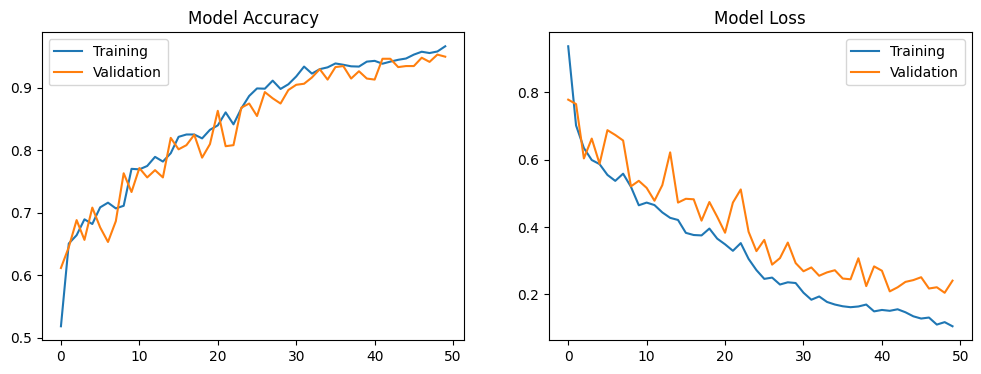

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.legend()

plt.show()
